# MLP do Zero — MNIST

Continuação direta do `MLP_XOR`. Tudo que foi desenvolvido lá, forward pass matricial, backpropagation em loop reverso, inicialização Xavier, ReLU configurável, é reutilizado aqui com as adaptações necessárias para classificação multiclasse em escala.

**O que muda em relação ao XOR:**

**Saída multiclasse:** camada de saída com 10 neurônios e softmax em vez de sigmoid binária.

**Função de perda:** cross-entropy em vez de MSE.

**Mini-batches:** atualização por batch em vez de por exemplo individual.

**Otimizador adicional:** Adam implementado junto com SGD para comparação.

**Escala:** 784 entradas, 60.000 exemplos de treino (tamanho fixo do dataset MNIST), duas camadas ocultas.

## Configuração

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras  #[Keras usado apenas para carregar o dataset — nenhuma camada ou modelo do Keras é utilizado]
from sklearn.decomposition import PCA  #[Usado apenas para visualização de embeddings — não treina nada]

np.random.seed(42)  #[Semente fixa para reproducibilidade dos experimentos]

## Testes unitários — funções de ativação e derivadas

Antes de implementar a rede completa, verifico se as funções de ativação e suas derivadas estão corretas contra valores conhecidos. Isso evita propagar um bug silencioso pelo restante do notebook.

A derivada da sigmoid em $z=0$ deve ser exatamente $0.25$, pois:

$$\sigma'(0) = \sigma(0)(1-\sigma(0)) = 0.5 \times 0.5 = 0.25$$

A ReLU em valores negativos deve retornar 0 e a derivada deve ser 0. Em valores positivos retorna o próprio valor e derivada 1.

In [ ]:
def sigmoid(z):        return 1 / (1 + np.exp(-z))
def sigmoid_deriv(a):  return a * (1 - a)
def relu(z):           return np.maximum(0, z)
def relu_deriv(a):     return (a > 0).astype(float)

def softmax(z):
    #[Subtrai o máximo por coluna para estabilidade numérica — evita overflow em e^z]
    z_est = z - np.max(z, axis=0, keepdims=True)
    exp_z = np.exp(z_est)
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)

def cross_entropy(y_pred, y_true):
    #[Clipa para evitar log(0)]
    y_pred = np.clip(y_pred, 1e-9, 1 - 1e-9)
    return -np.sum(y_true * np.log(y_pred), axis=0).mean()

def inicializar_xavier(n_entrada, n_saida):
    #[Xavier: W ~ U(-sqrt(1/n_in), sqrt(1/n_in)) — mantém variância estável entre camadas]
    limite = np.sqrt(1.0 / n_entrada)
    return np.random.uniform(-limite, limite, (n_saida, n_entrada)), np.zeros((n_saida, 1))

# ── Testes unitários ────────────────────────────────────────────────────────
def assert_close(val, esperado, nome, tol=1e-6):
    ok = abs(val - esperado) < tol
    status = 'OK' if ok else 'FALHOU'
    print(f'  [{status}] {nome}: obtido={val:.8f} | esperado={esperado:.8f}')
    return ok

print('=== Testes unitários ===')
# sigmoid
assert_close(sigmoid(0),              0.5,    'sigmoid(0) = 0.5')
assert_close(sigmoid(100),            1.0,    'sigmoid(100) ≈ 1', tol=1e-4)
assert_close(sigmoid(-100),           0.0,    'sigmoid(-100) ≈ 0', tol=1e-4)
# derivada da sigmoid
assert_close(sigmoid_deriv(0.5),      0.25,   'sigma_deriv(0.5) = 0.25')
assert_close(sigmoid_deriv(0.0),      0.0,    'sigma_deriv(0.0) = 0.0')
assert_close(sigmoid_deriv(1.0),      0.0,    'sigma_deriv(1.0) = 0.0')
# relu
assert_close(relu(-5.0),              0.0,    'relu(-5) = 0')
assert_close(relu(3.0),               3.0,    'relu(3) = 3')
# derivada da relu
assert_close(relu_deriv(np.array([2.0]))[0],  1.0, 'relu_deriv(2) = 1')
assert_close(relu_deriv(np.array([-1.0]))[0], 0.0, 'relu_deriv(-1) = 0')
# softmax: soma deve ser 1
z_test = np.array([[1.0],[2.0],[3.0]])
sm = softmax(z_test)
assert_close(sm.sum(), 1.0, 'softmax soma = 1')
print('========================')

=== Testes unitários ===
  [OK] sigmoid(0) = 0.5: obtido=0.50000000 | esperado=0.50000000
  [OK] sigmoid(100) ≈ 1: obtido=1.00000000 | esperado=1.00000000
  [OK] sigmoid(-100) ≈ 0: obtido=0.00000000 | esperado=0.00000000
  [OK] sigma_deriv(0.5) = 0.25: obtido=0.25000000 | esperado=0.25000000
  [OK] sigma_deriv(0.0) = 0.0: obtido=0.00000000 | esperado=0.00000000
  [OK] sigma_deriv(1.0) = 0.0: obtido=0.00000000 | esperado=0.00000000
  [OK] relu(-5) = 0: obtido=0.00000000 | esperado=0.00000000
  [OK] relu(3) = 3: obtido=3.00000000 | esperado=3.00000000
  [OK] relu_deriv(2) = 1: obtido=1.00000000 | esperado=1.00000000
  [OK] relu_deriv(-1) = 0: obtido=0.00000000 | esperado=0.00000000
  [OK] softmax soma = 1: obtido=1.00000000 | esperado=1.00000000


## Carregamento e pré-processamento

Cada imagem do MNIST é uma matriz 28×28 de valores entre 0 e 255. Três transformações necessárias:

**Achatar:** $28 \times 28 = 784$ — cada imagem vira um vetor coluna, que é a entrada da rede.

**Normalizar:** dividir por 255 coloca todos os valores em $[0, 1]$. Sem isso, os pesos da primeira camada precisariam compensar a escala de entrada e o gradiente seria instável.

**One-hot:** o rótulo $k$ vira o vetor $\mathbf{y}$ onde $y_k = 1$ e o resto é 0. É o que a cross-entropy espera.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Treino : X(60000, 784)  Y(60000, 10)
Teste  : X(10000, 784)   Y(10000, 10)


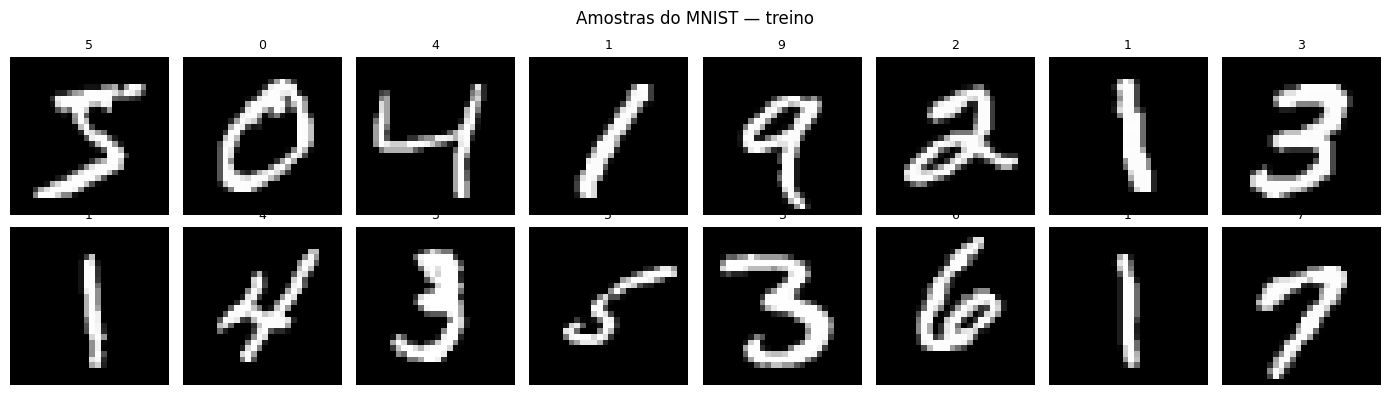

In [ ]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

#Achata cada imagem 28x28 em vetor de 784 valores e normaliza para [0, 1]
#[reshape(n, -1) transforma (60000, 28, 28) em (60000, 784) — o -1 infere a dimensão automaticamente]
X_train = X_train.reshape(X_train.shape[0], -1).astype(float) / 255.0
X_test  = X_test.reshape(X_test.shape[0],  -1).astype(float) / 255.0

def one_hot(y, n_classes=10):
    #[Converte rótulo escalar em vetor binário de tamanho n_classes]
    #[EX: 3 → [0,0,0,1,0,0,0,0,0,0] — cada posição representa uma classe]
    out = np.zeros((len(y), n_classes))
    out[np.arange(len(y)), y] = 1.0
    return out

Y_train = one_hot(y_train)  #shape (60000, 10)
Y_test  = one_hot(y_test)   #shape (10000, 10)

print(f'Treino : X{X_train.shape}  Y{Y_train.shape}')
print(f'Teste  : X{X_test.shape}   Y{Y_test.shape}')

#Visualização de 16 amostras
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for ax, img, label in zip(axes.flatten(), X_train[:16], y_train[:16]):
    ax.imshow(img.reshape(28, 28), cmap='gray')
    ax.set_title(str(label), fontsize=9)
    ax.axis('off')
plt.suptitle('Amostras do MNIST — treino')
plt.tight_layout(); plt.show()

## Softmax e Cross-Entropy

### Softmax

Para 10 classes a saída precisa ser uma distribuição de probabilidade — 10 valores positivos que somam 1:

$$\text{softmax}(z_i) = \frac{e^{z_i - \max(z)}}{\sum_{j=1}^{10} e^{z_j - \max(z)}}$$

A subtração do máximo não muda o resultado (cancela no numerador e denominador) mas evita `overflow` quando $z_i$ é grande.

### Cross-Entropy

O MSE penaliza erros quadraticamente e trata todos os erros de forma simétrica. Para classificação com softmax, a cross-entropy é mais adequada porque penaliza mais fortemente predições confiantes e erradas:

$$L = -\sum_{i=1}^{10} y_i \log(\hat{y}_i)$$

Como $\mathbf{y}$ é one-hot, apenas o termo da classe correta $c$ sobrevive:

$$L = -\log(\hat{y}_c)$$

### Gradiente simplificado

Derivando $L$ em relação ao pré-ativação $z_i$ da camada de saída (a combinação softmax + cross-entropy simplifica para):

$$\frac{\partial L}{\partial z_i} = \hat{y}_i - y_i$$

O delta da camada de saída é simplesmente **predito menos esperado**. O backprop da camada de saída fica idêntico ao do XOR, só com essa fórmula no lugar de $\sigma'(\hat{y}) \cdot \text{error}$.

## MLP_MNIST — SGD e Adam

A classe evolui diretamente da `MLPProfunda` (Teste 7) e `MLPAtivacaoConfig` (Teste 8) do MLP_XOR. A estrutura de lista de camadas, o forward em loop e o backprop reverso são os mesmos. O que foi adicionado:

**Adam como otimizador opcional.** O SGD usa uma taxa de aprendizado fixa $\alpha$ para todos os pesos. O Adam adapta a taxa de cada peso individualmente com base no histórico de gradientes:

$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t \quad \text{(momento de 1ª ordem)}$$
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2 \quad \text{(momento de 2ª ordem)}$$

Com correção de viés nas primeiras iterações (quando $m$ e $v$ ainda são próximos de zero):

$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$

Atualização:

$$W \leftarrow W - \alpha \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \varepsilon}$$

Os valores padrão $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\varepsilon = 10^{-8}$ são os mesmos do paper original. O Adam converge mais rápido que o SGD no MNIST porque ajusta o passo de cada peso conforme a magnitude do seu gradiente histórico.

In [ ]:
# A criação de uma classe permite não deixar as variáveis "despersas", com uma Classe, tudo que é pertencente a uma rede neural, fica nela
# EX: class MLP: | def train(self) pass | def predict(self) pass, podendo ser criado uma instância da rede neural, logo: rede = MLP() | rede.train() | rede.predict()
class MLP_MNIST:
  def __init__(self, camadas, otimizador='sgd'):
    #"__init__" é utilizado para iniciar atributos, nesse caso o "self"
    #[camadas é uma lista com o tamanho de cada camada, incluindo entrada e saída]
    #[EX: MLP_MNIST([784, 256, 128, 10]) → entrada 784, duas ocultas, saída 10 classes]
    #[otimizador: 'sgd' ou 'adam']
    self.camadas     = camadas
    self.otimizador  = otimizador
    self.historico_loss = []
    self.historico_acc  = []
    self._inicializar_pesos()

  def _inicializar_pesos(self):
    #[Cria uma lista de matrizes W e vetores b, um par por camada de conexão]
    #[Usa Xavier para todas as camadas — mantém variância estável durante o forward e o backprop]
    self.pesos  = []
    self.biases = []
    for i in range(len(self.camadas) - 1):
      W, b = inicializar_xavier(self.camadas[i], self.camadas[i + 1])
      self.pesos.append(W)
      self.biases.append(b)
    #[Momentos do Adam: m e v inicializados como zeros — shape igual aos pesos]
    self.m_W = [np.zeros_like(W) for W in self.pesos]
    self.v_W = [np.zeros_like(W) for W in self.pesos]
    self.m_b = [np.zeros_like(b) for b in self.biases]
    self.v_b = [np.zeros_like(b) for b in self.biases]
    self.t   = 0  #[Contador de passos para correção de viés do Adam]

  def _forward(self, X):
    #[X pode ser um batch inteiro: shape (n_entradas, batch_size)]
    #[Percorre a lista de pesos em sequência — cada camada recebe a saída da anterior]
    #[Guarda todas as ativações intermediárias pois o backprop vai precisar delas]
    ativacoes = [X]
    n_camadas = len(self.pesos)
    for idx, (W, b) in enumerate(zip(self.pesos, self.biases)):
      z = W @ ativacoes[-1] + b
      if idx == n_camadas - 1:
        #[Última camada: softmax — transforma os 10 logits em distribuição de probabilidade]
        ativacoes.append(softmax(z))
      else:
        #[Camadas ocultas: ReLU — não-linearidade sem vanishing gradient]
        ativacoes.append(relu(z))
    return ativacoes

  def _atualizar_sgd(self, k, dW, db, alpha):
    #[SGD: atualização direta com taxa de aprendizado fixa]
    #[W ← W - α * dW]
    self.pesos[k]  -= alpha * dW
    self.biases[k] -= alpha * db

  def _atualizar_adam(self, k, dW, db, alpha, b1=0.9, b2=0.999, eps=1e-8):
    #[Adam: atualização com taxa adaptativa por peso]
    self.t += 1
    #[Atualiza momentos de 1ª e 2ª ordem para W]
    self.m_W[k] = b1 * self.m_W[k] + (1 - b1) * dW
    self.v_W[k] = b2 * self.v_W[k] + (1 - b2) * dW**2
    #[Correção de viés — nas primeiras iterações m e v são subestimados]
    m_hat_W = self.m_W[k] / (1 - b1**self.t)
    v_hat_W = self.v_W[k] / (1 - b2**self.t)
    self.pesos[k] -= alpha * m_hat_W / (np.sqrt(v_hat_W) + eps)
    #[Mesmo processo para b]
    self.m_b[k] = b1 * self.m_b[k] + (1 - b1) * db
    self.v_b[k] = b2 * self.v_b[k] + (1 - b2) * db**2
    m_hat_b = self.m_b[k] / (1 - b1**self.t)
    v_hat_b = self.v_b[k] / (1 - b2**self.t)
    self.biases[k] -= alpha * m_hat_b / (np.sqrt(v_hat_b) + eps)

  def _backprop(self, ativacoes, Y_batch, alpha):
    #[Y_batch shape: (10, batch_size) — one-hot das classes corretas]
    n_camadas  = len(self.pesos)
    batch_size = Y_batch.shape[1]
    #[Delta da camada de saída: gradiente simplificado softmax + cross-entropy = predito - esperado]
    #[Dividir por batch_size já calcula a média do gradiente sobre o batch]
    delta = (ativacoes[-1] - Y_batch) / batch_size
    #[Percorre as camadas de trás pra frente, propagando o gradiente]
    for k in range(n_camadas - 1, -1, -1):
      #Calculo dos deltas que serão utilizados para atualização dos pesos
      dW = delta @ ativacoes[k].T
      db = delta.sum(axis=1, keepdims=True)
      #[Propaga o gradiente para a camada anterior antes de atualizar os pesos]
      if k > 0:
        delta = relu_deriv(ativacoes[k]) * (self.pesos[k].T @ delta)
      #Atualização dos pesos
      if self.otimizador == 'adam':
        self._atualizar_adam(k, dW, db, alpha)
      else:
        self._atualizar_sgd(k, dW, db, alpha)

  def train(self, X, Y, alpha, epochs, batch_size=64, X_val=None, Y_val=None):
    #Parâmetros que a função train deverá receber
    #[Aqui o self é essencial para chamar os parâmetros fora da função]
    #[X shape: (n_amostras, 784) | Y shape: (n_amostras, 10)]
    self.historico_loss = []
    self.historico_acc  = []
    n = X.shape[0]
    #LAÇOS DE REPETIÇÃO PARA TREINAMENTO
    for epoca in range(epochs):  #Iteração para a quantidade de épocas selecionadas
      #[Embaralha os dados a cada época para evitar que a ordem influencie o aprendizado]
      idx = np.random.permutation(n)
      X_s, Y_s = X[idx], Y[idx]
      loss_epoca, n_batches = 0.0, 0
      #[Loop sobre os mini-batches — cada batch atualiza os pesos uma vez]
      for start in range(0, n, batch_size):
        #[Fatia o batch atual — o último batch pode ter menos que batch_size exemplos]
        X_batch = X_s[start:start + batch_size].T  #shape (784, batch_size)
        Y_batch = Y_s[start:start + batch_size].T  #shape (10,  batch_size)
        #Execução de cálculos que serão passados adiantes (forward pass)
        ativacoes = self._forward(X_batch)
        #Calculamos o erro
        loss_epoca += cross_entropy(ativacoes[-1], Y_batch)
        n_batches  += 1
        #Calculo de derivadas parciais e atualização dos pesos (backpropagation)
        self._backprop(ativacoes, Y_batch, alpha)
      #[Após processar todos os batches da época, calcula métricas e salva no histórico]
      self.historico_loss.append(loss_epoca / n_batches)
      acc = self.evaluate(X_val if X_val is not None else X,
                          Y_val if Y_val is not None else Y)
      self.historico_acc.append(acc)
      if (epoca + 1) % 5 == 0 or epoca == 0:
        print(f'Época {epoca+1:>3}/{epochs} | loss: {self.historico_loss[-1]:.4f} | acc: {acc:.4f}')

  def embeddings(self, X):
    #[Retorna a ativação da penúltima camada — representação interna aprendida pela rede]
    ativacoes = self._forward(X.T)
    return ativacoes[-2].T  #shape (n_amostras, n_ocultos_ultima)

  def ativacoes_por_camada(self, X):
    #[Retorna lista de ativações de todas as camadas — usado para visualização de neurônios mortos]
    return self._forward(X.T)  #lista de arrays, cada um shape (n_neurônios, n_amostras)

  def predict(self, X):
    #[predict agora usa os pesos salvos em self — não precisa receber a tupla de pesos como parâmetro]
    #[X shape: (n_amostras, 784)]
    ativacoes = self._forward(X.T)
    #[Retorna o índice da classe com maior probabilidade para cada exemplo]
    return np.argmax(ativacoes[-1], axis=0)

  def evaluate(self, X, Y):
    #[Y shape: (n_amostras, 10) — one-hot]
    return np.mean(self.predict(X) == np.argmax(Y, axis=1))

## Gradient Check

Antes de treinar no MNIST completo, verifico se o backpropagation está correto comparando o gradiente analítico com a aproximação numérica por diferença finita central:

$$\frac{\partial L}{\partial \theta} \approx \frac{L(\theta + \varepsilon) - L(\theta - \varepsilon)}{2\varepsilon}$$

A diferença relativa entre os dois deve ser menor que $10^{-4}$. Se estiver maior, há um bug no backprop.

In [ ]:
def gradient_check(rede, X_sample, Y_sample, eps=1e-5, n_checks=20):
    #[Gradient check: compara gradiente analítico com gradiente numérico]
    #[X_sample shape: (784, 1) | Y_sample shape: (10, 1) — um único exemplo]
    ativacoes = rede._forward(X_sample)
    #Calcula gradiente analítico via forward + backprop
    delta = (ativacoes[-1] - Y_sample)
    grads_W = []
    ativ = list(ativacoes)
    for k in range(len(rede.pesos) - 1, -1, -1):
        dW = delta @ ativ[k].T
        grads_W.insert(0, dW.copy())
        if k > 0:
            delta = relu_deriv(ativ[k]) * (rede.pesos[k].T @ delta)
    #Compara com gradiente numérico para n_checks pesos da primeira camada
    erros_rel = []
    W0 = rede.pesos[0]
    dW0 = grads_W[0]
    indices = [(i, j) for i in range(min(5, W0.shape[0]))
                      for j in range(min(4, W0.shape[1]))][:n_checks]
    for i, j in indices:
        #[Perturba o peso (i,j) para cima e para baixo]
        W0[i, j] += eps
        lp = cross_entropy(rede._forward(X_sample)[-1], Y_sample)
        W0[i, j] -= 2 * eps
        ln = cross_entropy(rede._forward(X_sample)[-1], Y_sample)
        W0[i, j] += eps
        grad_num  = (lp - ln) / (2 * eps)
        dif_rel = abs(grad_num - dW0[i,j]) / (abs(grad_num) + abs(dW0[i,j]) + 1e-10)
        erros_rel.append(dif_rel)
    print(f'Gradient check ({n_checks} pesos da camada 0)')
    print(f'  Diferença relativa máxima: {max(erros_rel):.2e}')
    print(f'  Diferença relativa média:  {np.mean(erros_rel):.2e}')
    print(f'  Resultado: {"OK" if max(erros_rel) < 1e-4 else "ATENÇÃO — verificar backprop"}')

rede_gc = MLP_MNIST([784, 16, 10])
gradient_check(rede_gc, X_train[0:1].T, Y_train[0:1].T)

Gradient check (20 pesos da camada 0)
  Diferença relativa máxima: 0.00e+00
  Diferença relativa média:  0.00e+00
  Resultado: OK


## Experimento 1 — Configuração base (SGD)

Primeira configuração: arquitetura `784 → 256 → 128 → 10`, que segue a heurística de redução progressiva discutida na documentação.

**`alpha = 0.01`** — conservador. No XOR funcionou `alpha=0.1`, mas com 784 entradas o gradiente acumula de mais fontes e um passo maior pode causar oscilação.

**`batch_size = 64`** — Atualiza os pesos $\frac{60000}{64} \approx 937$ vezes por época.

**`epochs = 30`** — suficiente para observar convergência no Colab.

In [ ]:
#Configuração base: 784 → 256 → 128 → 10
#[Arquitetura definida na documentação seguindo heurística de redução progressiva]
rede_base = MLP_MNIST([784, 256, 128, 10], otimizador='sgd')
rede_base.train(X_train, Y_train, alpha=0.01, epochs=30,
                batch_size=64, X_val=X_test, Y_val=Y_test)
acc_base = rede_base.evaluate(X_test, Y_test)
print(f'\nAcurácia final no teste: {acc_base:.4f} ({acc_base*100:.2f}%)')

Época   1/30 | loss: 1.6539 | acc: 0.8153
Época   5/30 | loss: 0.3099 | acc: 0.9172
Época  10/30 | loss: 0.2268 | acc: 0.9367
Época  15/30 | loss: 0.1735 | acc: 0.9485
Época  20/30 | loss: 0.1377 | acc: 0.9589
Época  25/30 | loss: 0.1119 | acc: 0.9648
Época  30/30 | loss: 0.0925 | acc: 0.9687

Acurácia final no teste: 0.9687 (96.87%)


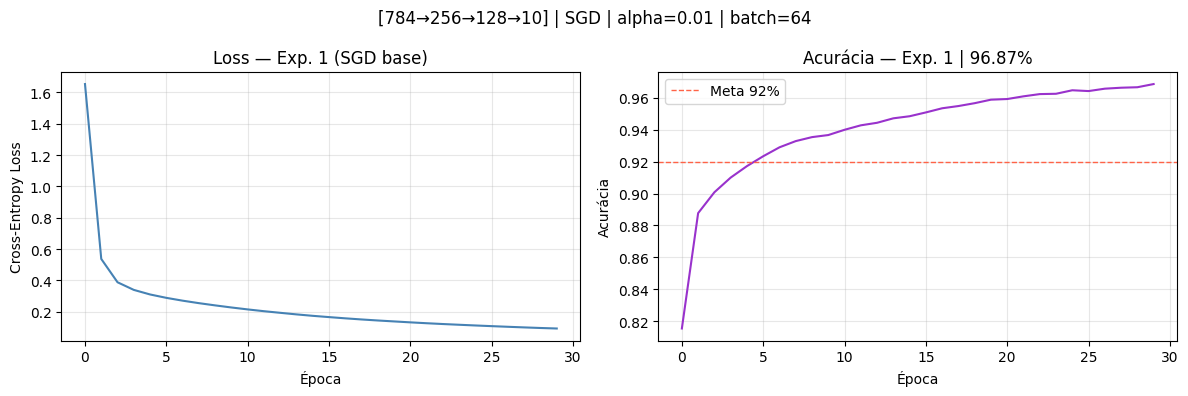

In [7]:
#Plot da curva de loss e acurácia ao longo do treinamento
#[O eixo x representa as épocas — queremos ver queda consistente na loss e subida na acurácia]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(rede_base.historico_loss, color='steelblue', linewidth=1.5)
ax1.set_xlabel('Época'); ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Loss — Exp. 1 (SGD base)'); ax1.grid(True, alpha=0.3)
ax2.plot(rede_base.historico_acc, color='darkorchid', linewidth=1.5)
ax2.axhline(0.92, color='tomato', linestyle='--', linewidth=1, label='Meta 92%')
ax2.set_xlabel('Época'); ax2.set_ylabel('Acurácia')
ax2.set_title(f'Acurácia — Exp. 1 | {acc_base*100:.2f}%'); ax2.legend()
ax2.grid(True, alpha=0.3)
plt.suptitle('[784→256→128→10] | SGD | alpha=0.01 | batch=64')
plt.tight_layout(); plt.show()

## Experimento 2 — Comparação de configurações

Comparo quatro variações para cobrir o requisito obrigatório da ponderada e entender o espaço de hiperparâmetros:

**Config A (base):** `[784, 256, 128, 10]` | SGD | `alpha=0.01` | `batch=64`

**Config B (rede menor):** `[784, 128, 64, 10]` | SGD | `alpha=0.01` | `batch=64` — menos parâmetros. Testa se a rede base está superdimensionada.

**Config C (alpha maior):** `[784, 256, 128, 10]` | SGD | `alpha=0.05` | `batch=64` — mesma arquitetura, passo maior.

**Config D (Adam):** `[784, 256, 128, 10]` | Adam | `alpha=0.001` | `batch=64` — Adam usa `alpha` menor porque adapta internamente por peso.

In [8]:
#Configurações a comparar
#[Cada tupla: (nome, camadas, otimizador, alpha, batch_size, cor_no_plot)]
configs = [
    ('A — SGD base',   [784, 256, 128, 10], 'sgd',  0.010,  64, 'steelblue'),
    ('B — SGD menor',  [784, 128,  64, 10], 'sgd',  0.010,  64, 'darkorchid'),
    ('C — SGD a=0.05', [784, 256, 128, 10], 'sgd',  0.050,  64, 'seagreen'),
    ('D — Adam',       [784, 256, 128, 10], 'adam', 0.001,  64, 'darkorange'),
]

resultados = {}
for nome, camadas, otim, alpha, batch, _ in configs:
    print(f'\n=== {nome} ===')
    rede = MLP_MNIST(camadas, otimizador=otim)
    rede.train(X_train, Y_train, alpha=alpha, epochs=30,
               batch_size=batch, X_val=X_test, Y_val=Y_test)
    acc = rede.evaluate(X_test, Y_test)
    resultados[nome] = {'rede': rede, 'acc': acc, 'camadas': camadas,
                        'otim': otim, 'alpha': alpha, 'batch': batch}
    print(f'Acurácia final: {acc:.4f} ({acc*100:.2f}%)')


=== A — SGD base ===
Época   1/30 | loss: 1.7327 | acc: 0.8196
Época   5/30 | loss: 0.3135 | acc: 0.9171
Época  10/30 | loss: 0.2233 | acc: 0.9389
Época  15/30 | loss: 0.1673 | acc: 0.9511
Época  20/30 | loss: 0.1312 | acc: 0.9629
Época  25/30 | loss: 0.1064 | acc: 0.9668
Época  30/30 | loss: 0.0887 | acc: 0.9684
Acurácia final: 0.9684 (96.84%)

=== B — SGD menor ===
Época   1/30 | loss: 1.7718 | acc: 0.7893
Época   5/30 | loss: 0.3166 | acc: 0.9119
Época  10/30 | loss: 0.2307 | acc: 0.9350
Época  15/30 | loss: 0.1763 | acc: 0.9495
Época  20/30 | loss: 0.1407 | acc: 0.9566
Época  25/30 | loss: 0.1155 | acc: 0.9634
Época  30/30 | loss: 0.0966 | acc: 0.9675
Acurácia final: 0.9675 (96.75%)

=== C — SGD a=0.05 ===
Época   1/30 | loss: 0.6845 | acc: 0.9097
Época   5/30 | loss: 0.1279 | acc: 0.9641
Época  10/30 | loss: 0.0591 | acc: 0.9739
Época  15/30 | loss: 0.0326 | acc: 0.9778
Época  20/30 | loss: 0.0179 | acc: 0.9786
Época  25/30 | loss: 0.0099 | acc: 0.9802
Época  30/30 | loss: 0.0058

            Config   Otim    Alpha      Acc
--------------------------------------------
      A — SGD base    sgd     0.01   0.9684
     B — SGD menor    sgd     0.01   0.9675
    C — SGD a=0.05    sgd     0.05   0.9798
          D — Adam   adam    0.001   0.9800


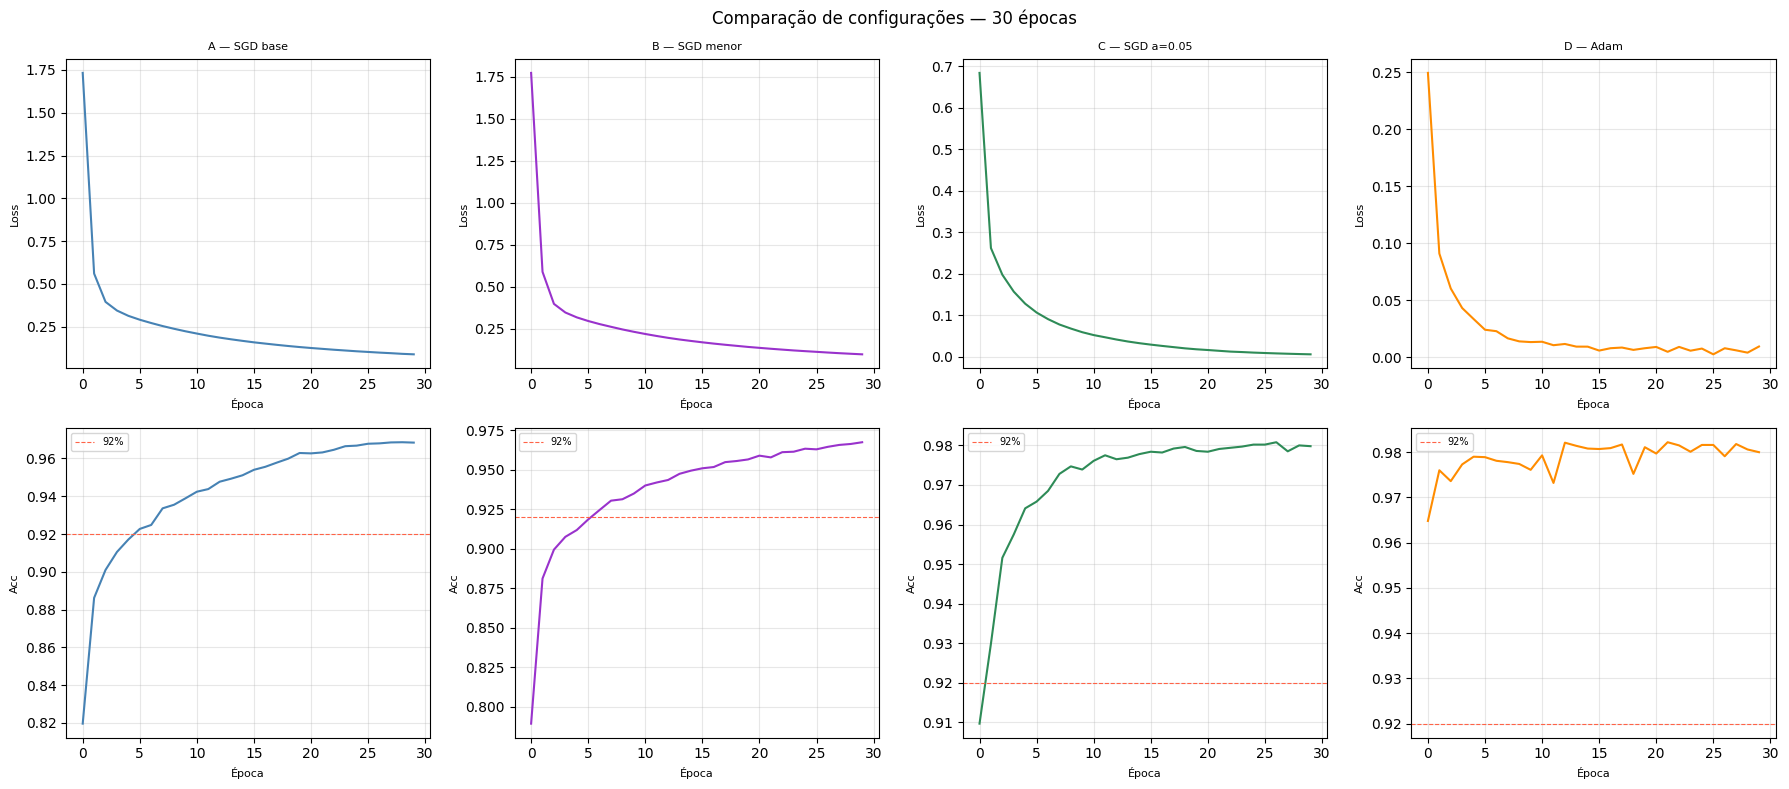

In [9]:
#Plot comparativo
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
print(f"{'Config':>18}  {'Otim':>5}  {'Alpha':>7}  {'Acc':>7}")
print('-' * 44)
for col, (nome, cfg) in enumerate(resultados.items()):
    rede = cfg['rede']; cor = configs[col][5]
    axes[0, col].plot(rede.historico_loss, color=cor, linewidth=1.5)
    axes[0, col].set_title(nome, fontsize=8)
    axes[0, col].set_xlabel('Época', fontsize=8); axes[0, col].set_ylabel('Loss', fontsize=8)
    axes[0, col].grid(True, alpha=0.3)
    axes[1, col].plot(rede.historico_acc, color=cor, linewidth=1.5)
    axes[1, col].axhline(0.92, color='tomato', linestyle='--', linewidth=0.8, label='92%')
    axes[1, col].set_xlabel('Época', fontsize=8); axes[1, col].set_ylabel('Acc', fontsize=8)
    axes[1, col].legend(fontsize=7); axes[1, col].grid(True, alpha=0.3)
    print(f"{nome:>18}  {cfg['otim']:>5}  {cfg['alpha']:>7}  {cfg['acc']:>7.4f}")
plt.suptitle('Comparação de configurações — 30 épocas')
plt.tight_layout(); plt.show()

## Treinamento final — melhor configuração

Com base nos experimentos anteriores, treino a melhor configuração por 50 épocas para consolidar o resultado.

Mais épocas só fazem sentido se a curva de loss ainda estava em queda ao final das 30 épocas. Se já havia estabilizado, o gargalo é a arquitetura, não o tempo de treino.

In [10]:
#Identifica a melhor configuração pelo resultado dos experimentos
melhor_nome = max(resultados, key=lambda k: resultados[k]['acc'])
melhor = resultados[melhor_nome]
print(f'Melhor config: {melhor_nome} | acc={melhor["acc"]:.4f}')

rede_final = MLP_MNIST(melhor['camadas'], otimizador=melhor['otim'])
rede_final.train(X_train, Y_train, alpha=melhor['alpha'], epochs=50,
                 batch_size=melhor['batch'], X_val=X_test, Y_val=Y_test)
acc_final = rede_final.evaluate(X_test, Y_test)
print(f'\nAcurácia final (50 épocas): {acc_final:.4f} ({acc_final*100:.2f}%)')

Melhor config: D — Adam | acc=0.9800
Época   1/50 | loss: 0.2584 | acc: 0.9509
Época   5/50 | loss: 0.0309 | acc: 0.9777
Época  10/50 | loss: 0.0133 | acc: 0.9797
Época  15/50 | loss: 0.0088 | acc: 0.9774
Época  20/50 | loss: 0.0102 | acc: 0.9809
Época  25/50 | loss: 0.0066 | acc: 0.9809
Época  30/50 | loss: 0.0041 | acc: 0.9815
Época  35/50 | loss: 0.0062 | acc: 0.9805
Época  40/50 | loss: 0.0051 | acc: 0.9802
Época  45/50 | loss: 0.0037 | acc: 0.9821
Época  50/50 | loss: 0.0044 | acc: 0.9828

Acurácia final (50 épocas): 0.9828 (98.28%)


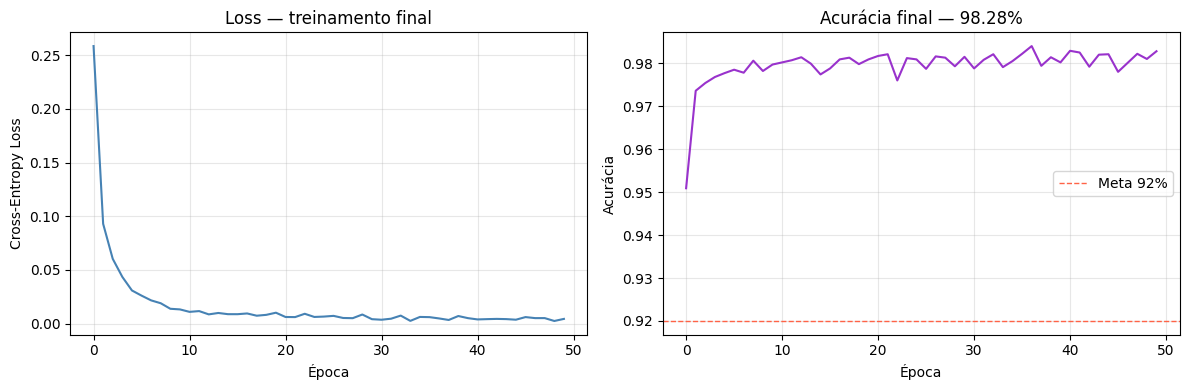

In [11]:
#Plot do treinamento final
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(rede_final.historico_loss, color='steelblue', linewidth=1.5)
ax1.set_xlabel('Época'); ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Loss — treinamento final'); ax1.grid(True, alpha=0.3)
ax2.plot(rede_final.historico_acc, color='darkorchid', linewidth=1.5)
ax2.axhline(0.92, color='tomato', linestyle='--', linewidth=1, label='Meta 92%')
ax2.set_xlabel('Época'); ax2.set_ylabel('Acurácia')
ax2.set_title(f'Acurácia final — {acc_final*100:.2f}%'); ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Matriz de confusão

A diagonal principal são os acertos. Fora dela estão os erros — cada célula $(i, j)$ fora da diagonal mostra quantos exemplos da classe $i$ foram preditos como classe $j$.

Para o MNIST alguns pares de dígitos são visualmente similares: 4 e 9, 3 e 8, 1 e 7. Erros concentrados nesses pares são esperados.

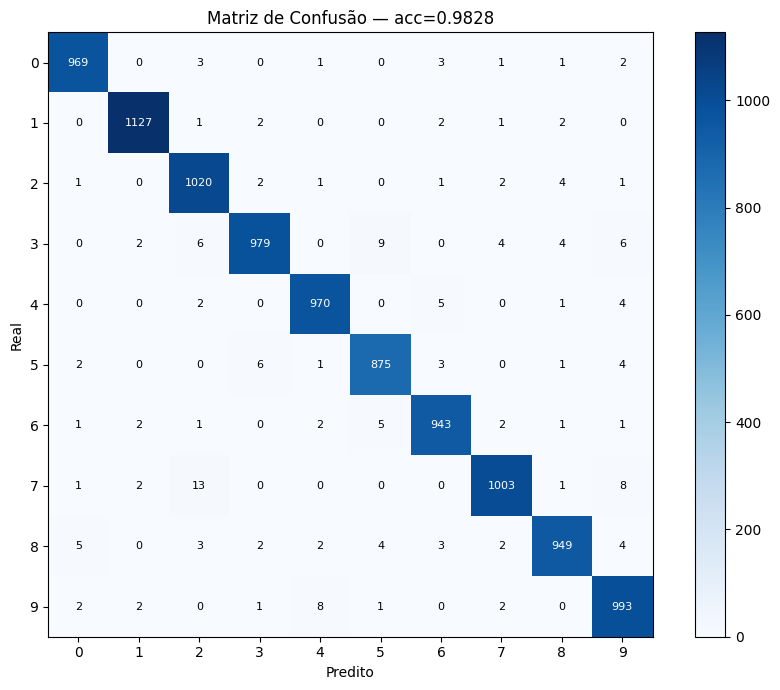

Acurácia por dígito:
  Dígito 0: 0.9888 (969/980) — principal confusão com 2 (3 erros)
  Dígito 1: 0.9930 (1127/1135) — principal confusão com 3 (2 erros)
  Dígito 2: 0.9884 (1020/1032) — principal confusão com 8 (4 erros)
  Dígito 3: 0.9693 (979/1010) — principal confusão com 5 (9 erros)
  Dígito 4: 0.9878 (970/982) — principal confusão com 6 (5 erros)
  Dígito 5: 0.9809 (875/892) — principal confusão com 3 (6 erros)
  Dígito 6: 0.9843 (943/958) — principal confusão com 5 (5 erros)
  Dígito 7: 0.9757 (1003/1028) — principal confusão com 2 (13 erros)
  Dígito 8: 0.9743 (949/974) — principal confusão com 0 (5 erros)
  Dígito 9: 0.9841 (993/1009) — principal confusão com 4 (8 erros)


In [12]:
preds_test  = rede_final.predict(X_test)
labels_test = np.argmax(Y_test, axis=1)

#Constrói a matriz de confusão manualmente
#[mat[i, j] = número de exemplos da classe i preditos como classe j]
mat = np.zeros((10, 10), dtype=int)
for real, pred in zip(labels_test, preds_test):
    mat[real, pred] += 1

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(mat, cmap='Blues')
plt.colorbar(im)
for i in range(10):
    for j in range(10):
        cor_txt = 'white' if mat[i, j] > mat.max() * 0.5 else 'black'
        ax.text(j, i, str(mat[i, j]), ha='center', va='center', fontsize=8, color=cor_txt)
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel('Predito'); ax.set_ylabel('Real')
ax.set_title(f'Matriz de Confusão — acc={acc_final:.4f}')
plt.tight_layout(); plt.show()

#Acurácia por classe
print('Acurácia por dígito:')
erros_pares = []
for i in range(10):
    acc_i = mat[i, i] / mat[i].sum()
    mais_conf = mat[i].copy(); mais_conf[i] = 0
    j_conf = mais_conf.argmax()
    n_conf = mais_conf[j_conf]
    erros_pares.append((n_conf, i, j_conf))
    print(f'  Dígito {i}: {acc_i:.4f} ({mat[i,i]}/{mat[i].sum()}) — principal confusão com {j_conf} ({n_conf} erros)')

## Visualização de ativações internas

Neurônios mortos são neurônios onde a ReLU retorna 0 para praticamente todos os exemplos do conjunto de teste. Quando um neurônio está sempre inativo, seus pesos não recebem gradiente e param de ser atualizados, ele para de contribuir para a rede.

Um histograma das ativações de cada camada oculta mostra a distribuição de valores. Se uma grande fração estiver em zero, há neurônios mortos, o que pode indicar `alpha` muito alto ou inicialização ruim.

Camada oculta 1: 79.8% de ativações em zero
Camada oculta 2: 65.8% de ativações em zero


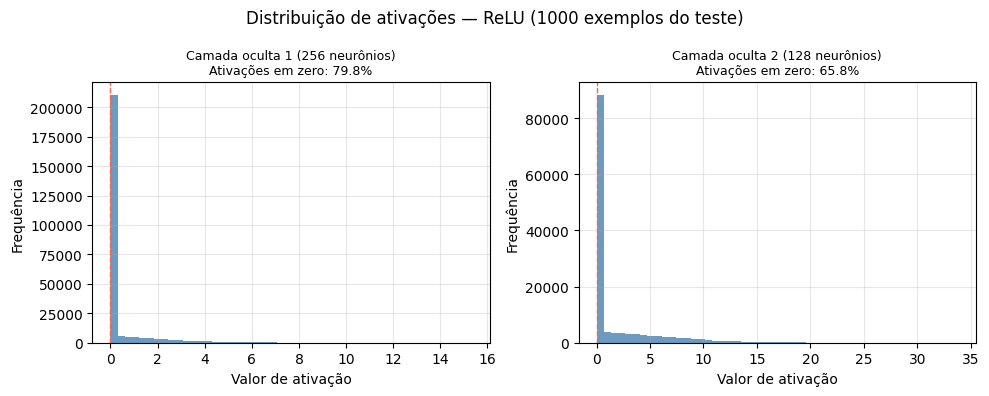

In [13]:
#Calcula ativações de todas as camadas para os primeiros 1000 exemplos do teste
#[1000 exemplos é suficiente para ver a distribuição sem custo computacional alto]
ativs = rede_final.ativacoes_por_camada(X_test[:1000])

#Plota histograma das camadas ocultas (índices 1 e 2 — índice 0 é a entrada, -1 é a saída)
n_ocultas = len(rede_final.camadas) - 2
fig, axes = plt.subplots(1, n_ocultas, figsize=(5 * n_ocultas, 4))
if n_ocultas == 1: axes = [axes]

for i, ax in enumerate(axes):
    a = ativs[i + 1].flatten()  #ativação da camada oculta i+1
    pct_mortos = (a == 0).mean() * 100
    ax.hist(a, bins=50, color='steelblue', edgecolor='none', alpha=0.8)
    ax.axvline(0, color='tomato', linestyle='--', linewidth=1)
    ax.set_title(f'Camada oculta {i+1} ({rede_final.camadas[i+1]} neurônios)\n'
                 f'Ativações em zero: {pct_mortos:.1f}%', fontsize=9)
    ax.set_xlabel('Valor de ativação'); ax.set_ylabel('Frequência')
    ax.grid(True, alpha=0.3)
    print(f'Camada oculta {i+1}: {pct_mortos:.1f}% de ativações em zero')

plt.suptitle('Distribuição de ativações — ReLU (1000 exemplos do teste)')
plt.tight_layout(); plt.show()

## Visualização de embeddings via PCA

A saída da penúltima camada (128 neurônios) é a representação interna que a rede aprendeu para cada imagem. Essa representação tem 128 dimensões, inviável de visualizar diretamente.

O PCA reduz para 2 dimensões preservando a maior variância possível. Se a rede aprendeu bem, dígitos da mesma classe deveriam estar agrupados no espaço 2D.

O PCA é uma transformação linear que encontra as direções de maior variância nos dados:

$$\mathbf{Z} = \mathbf{X} \mathbf{V}_k$$

Onde $\mathbf{V}_k$ são os $k$ autovetores da matriz de covariância de $\mathbf{X}$ com maiores autovalores. Aqui $k=2$.

Variância explicada pelos 2 componentes: 30.6%


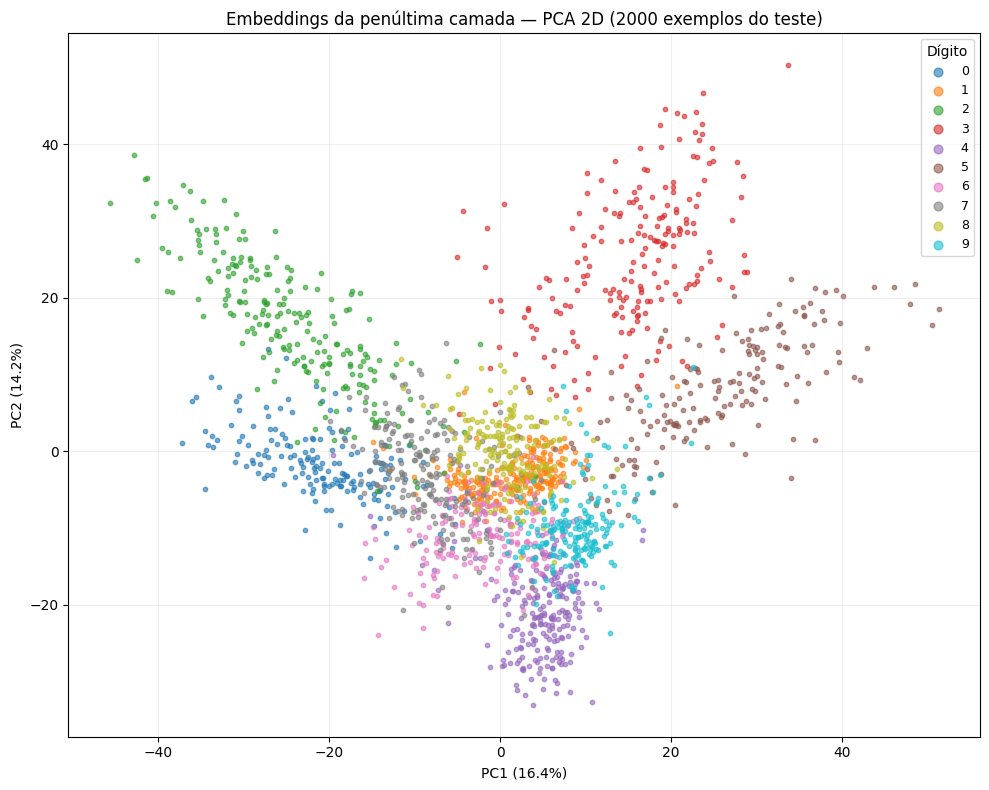

In [14]:
#Extrai embeddings da penúltima camada para 2000 exemplos do teste
#[2000 é um bom equilíbrio entre clareza visual e custo computacional]
n_amostras = 2000
emb = rede_final.embeddings(X_test[:n_amostras])  #shape (2000, 128)
labels_emb = y_test[:n_amostras]

#Reduz para 2 dimensões via PCA
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(emb)  #shape (2000, 2)
print(f'Variância explicada pelos 2 componentes: {pca.explained_variance_ratio_.sum()*100:.1f}%')

#Plot — cada cor é uma classe
fig, ax = plt.subplots(figsize=(10, 8))
cores = plt.cm.tab10(np.linspace(0, 1, 10))
for digito in range(10):
    mask = labels_emb == digito
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
               color=cores[digito], label=str(digito),
               s=10, alpha=0.6)
ax.legend(title='Dígito', markerscale=2, fontsize=9)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Embeddings da penúltima camada — PCA 2D (2000 exemplos do teste)')
ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

## Exemplos de erro

Ver os exemplos que a rede errou é mais informativo do que olhar só a acurácia. Muitos erros são exemplos genuinamente ambíguos que até um humano teria dificuldade de classificar.

Total de erros: 172 de 10000 (1.72%)


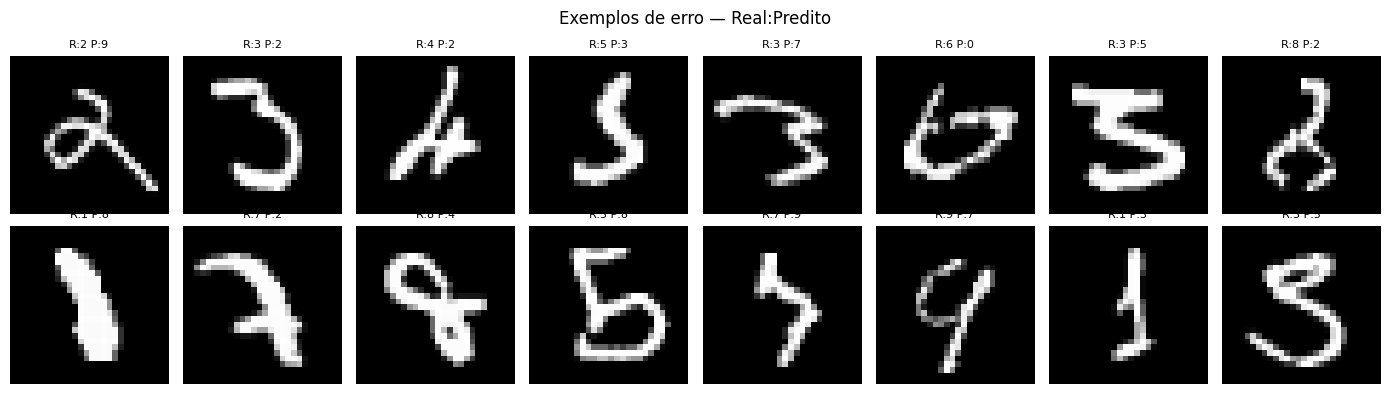

In [15]:
#Encontra os exemplos que a rede errou no conjunto de teste
erros_idx = np.where(preds_test != labels_test)[0]
print(f'Total de erros: {len(erros_idx)} de {len(labels_test)} ({len(erros_idx)/len(labels_test)*100:.2f}%)')

#Mostra os primeiros 16 erros
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for ax, idx in zip(axes.flatten(), erros_idx[:16]):
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f'R:{labels_test[idx]} P:{preds_test[idx]}', fontsize=8)
    ax.axis('off')
plt.suptitle('Exemplos de erro — Real:Predito')
plt.tight_layout(); plt.show()